# Linear Regression with Regularization: OLS, Lasso (L1), and Ridge (L2)

**Author:** Iván de Luna  
**Data:** ENIGH 2022 — Encuesta Nacional de Ingresos y Gastos de los Hogares (INEGI, Mexico)  
**Topics:** Linear Regression · Regularization · Feature Selection · Cross-Validation

---

## Overview

When modeling household income with many correlated predictors, standard OLS regression can become unstable: coefficients may be large, noisy, and hard to interpret. **Regularization** addresses this by adding a penalty term to the loss function that discourages overly complex models.

This notebook compares three regression approaches applied to Mexican household survey data:

| Method | Penalty | Effect |
|--------|---------|--------|
| **OLS** | None | Unbiased estimates; sensitive to multicollinearity |
| **Lasso (L1)** | $\lambda \sum |\beta_j|$ | Shrinks some coefficients to exactly zero → automatic variable selection |
| **Ridge (L2)** | $\lambda \sum \beta_j^2$ | Shrinks all coefficients toward zero; keeps all variables |

The key tuning parameter $\lambda$ (called `alpha` in scikit-learn) controls the strength of the penalty. A larger $\lambda$ produces more shrinkage. We select the optimal $\lambda$ via **5-fold cross-validation**.

### Contents
- [1. Data & Preprocessing](#data)
- [2. Exploratory Analysis](#eda)
- [3. OLS Regression](#ols)
- [4. Lasso Regression](#lasso)
- [5. Ridge Regression](#ridge)
- [6. Model Comparison](#comparison)
- [7. Summary](#summary)

### Requirements
```
pandas, numpy, matplotlib, seaborn, scikit-learn
```

In [2]:
# --- Dependencies ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

np.random.seed(42)

<a id='data'></a>
## 1. Data & Preprocessing

### About the ENIGH

The **Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH)** is Mexico's national household income and expenditure survey, published by INEGI every two years. The 2022 edition covers **91,414 households** across the country and includes 126 variables on income sources, expenditure categories, household composition, and socioeconomic characteristics.

We use the `concentradohogar` table, which aggregates the main income and expenditure variables at the household level.

**Download the data:**  
→ [ENIGH 2022 — Microdatos (INEGI)](https://www.inegi.org.mx/programas/enigh/nc/2022/#documentacion)  
Select *"Principales variables por hogar (concentradohogar.*)"* and download the `.csv` file. Place it in the same directory as this notebook.

### Model

We model **quarterly household income** (`ing_cor`) as a function of household characteristics and expenditure components:

$$\text{ing\_cor} = \beta_0 + \beta_1\,\text{edad\_jefe} + \beta_2\,\text{educa\_jefe} + \beta_3\,\text{tot\_integ} + \beta_4\,\text{mujer\_jefe} + \sum_{k}\beta_k\,\text{gasto}_k + \varepsilon$$

### Variable Dictionary

| Variable | Description |
|----------|-------------|
| `ing_cor` | Quarterly household current income (MXN) — **target** |
| `edad_jefe` | Age of household head |
| `educa_jefe` | Education level of household head (1–11 scale) |
| `tot_integ` | Total household members |
| `mujer_jefe` | Binary: 1 if household head is female |
| `gasto_mon` | Total monetary expenditure |
| `alimentos` | Food expenditure |
| `vesti_calz` | Clothing and footwear |
| `vivienda` | Housing |
| `limpieza` | Cleaning and household goods |
| `salud` | Health |
| `transporte` | Transportation |
| `educa_espa` | Education and entertainment |
| `personales` | Personal care |
| `transf_gas` | Transfer expenditures |

In [3]:
# --- Load data ---
df = pd.read_csv('concentradohogar.csv', encoding='latin1')
print(f'Dataset: {df.shape[0]:,} households × {df.shape[1]} variables')

# Select variables of interest
FEATURES = [
    'edad_jefe', 'educa_jefe', 'tot_integ',
    'gasto_mon', 'alimentos', 'vesti_calz', 'vivienda',
    'limpieza', 'salud', 'transporte', 'educa_espa',
    'personales', 'transf_gas'
]
TARGET = 'ing_cor'

df_model = df[FEATURES + [TARGET, 'sexo_jefe']].copy()
print(f'Missing values: {df_model.isnull().sum().sum()}')
df_model.describe().round(0)

Dataset: 91,414 households × 126 variables
Missing values: 0


,edad_jefe,educa_jefe,tot_integ,gasto_mon,alimentos,vesti_calz,vivienda,limpieza,salud,transporte,educa_espa,personales,transf_gas,ing_cor,sexo_jefe
count,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0
mean,52.0,6.0,3.0,43411.0,16357.0,1635.0,3705.0,2811.0,1523.0,8863.0,3792.0,3488.0,1238.0,72274.0,1.0
std,16.0,3.0,2.0,38696.0,11753.0,2804.0,5609.0,4638.0,6310.0,16036.0,9144.0,4515.0,5441.0,93877.0,0.0
min,14.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
25%,39.0,4.0,2.0,21524.0,8718.0,0.0,1053.0,914.0,0.0,2400.0,0.0,1153.0,0.0,34521.0,1.0
50%,51.0,6.0,3.0,34183.0,13898.0,783.0,2211.0,1674.0,191.0,5700.0,834.0,2246.0,0.0,55666.0,1.0
75%,63.0,8.0,4.0,53047.0,20893.0,2054.0,4161.0,3066.0,1042.0,10633.0,3809.0,4184.0,245.0,88841.0,2.0
max,106.0,11.0,20.0,1635931.0,314460.0,110152.0,190500.0,592928.0,493043.0,1315006.0,336507.0,211575.0,373390.0,17431978.0,2.0


### Handling Outliers

The income variable has extreme right-skew: the 99th percentile is ~310k MXN/quarter while the maximum exceeds 17 million. These outliers are legitimate (very high-income households do exist in Mexico) but they strongly distort regression coefficients.

We apply **winsorizing at the 99th percentile** — capping values above that threshold — which retains 99% of the data while removing the influence of extreme observations. This is a standard practice in income modeling.

In [4]:
# --- Winsorize income at 99th percentile ---
p99 = df_model[TARGET].quantile(0.99)
n_before = len(df_model)
df_model = df_model[df_model[TARGET] <= p99].copy()
n_after = len(df_model)

print(f'99th percentile cap : MXN {p99:,.0f}/quarter')
print(f'Observations removed: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.1f}%)')
print(f'Final dataset       : {n_after:,} households')

# --- Binary dummy: female household head ---
# sexo_jefe: 1 = male, 2 = female
df_model['mujer_jefe'] = (df_model['sexo_jefe'] == 2).astype(int)
df_model = df_model.drop(columns=['sexo_jefe'])

print(f"\nFemale-headed households: {df_model['mujer_jefe'].sum():,} ({df_model['mujer_jefe'].mean()*100:.1f}%)")

99th percentile cap : MXN 309,772/quarter
Observations removed: 915 (1.0%)
Final dataset       : 90,499 households

Female-headed households: 29,389 (32.5%)


<a id='eda'></a>
## 2. Exploratory Analysis

### Income Distribution

Before modeling, we examine the distribution of our target variable and the correlation structure among predictors. High correlations between expenditure categories are expected — and are precisely what regularization is designed to handle.

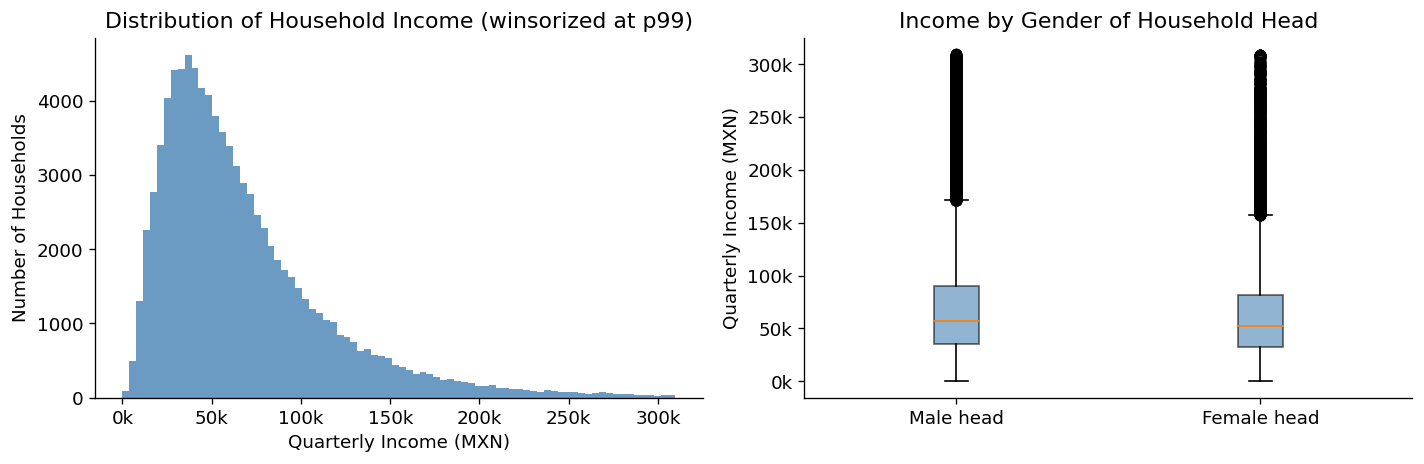

Mean income — Male head  : MXN 69,771
Mean income — Female head: MXN 63,921


In [5]:
# --- Income distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model[TARGET], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].set_xlabel('Quarterly Income (MXN)')
axes[0].set_ylabel('Number of Households')
axes[0].set_title('Distribution of Household Income (winsorized at p99)')

axes[1].boxplot(
    [df_model[df_model['mujer_jefe']==0][TARGET],
     df_model[df_model['mujer_jefe']==1][TARGET]],
    labels=['Male head', 'Female head'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].set_ylabel('Quarterly Income (MXN)')
axes[1].set_title('Income by Gender of Household Head')

plt.tight_layout()
plt.show()

print(f"Mean income — Male head  : MXN {df_model[df_model['mujer_jefe']==0][TARGET].mean():,.0f}")
print(f"Mean income — Female head: MXN {df_model[df_model['mujer_jefe']==1][TARGET].mean():,.0f}")

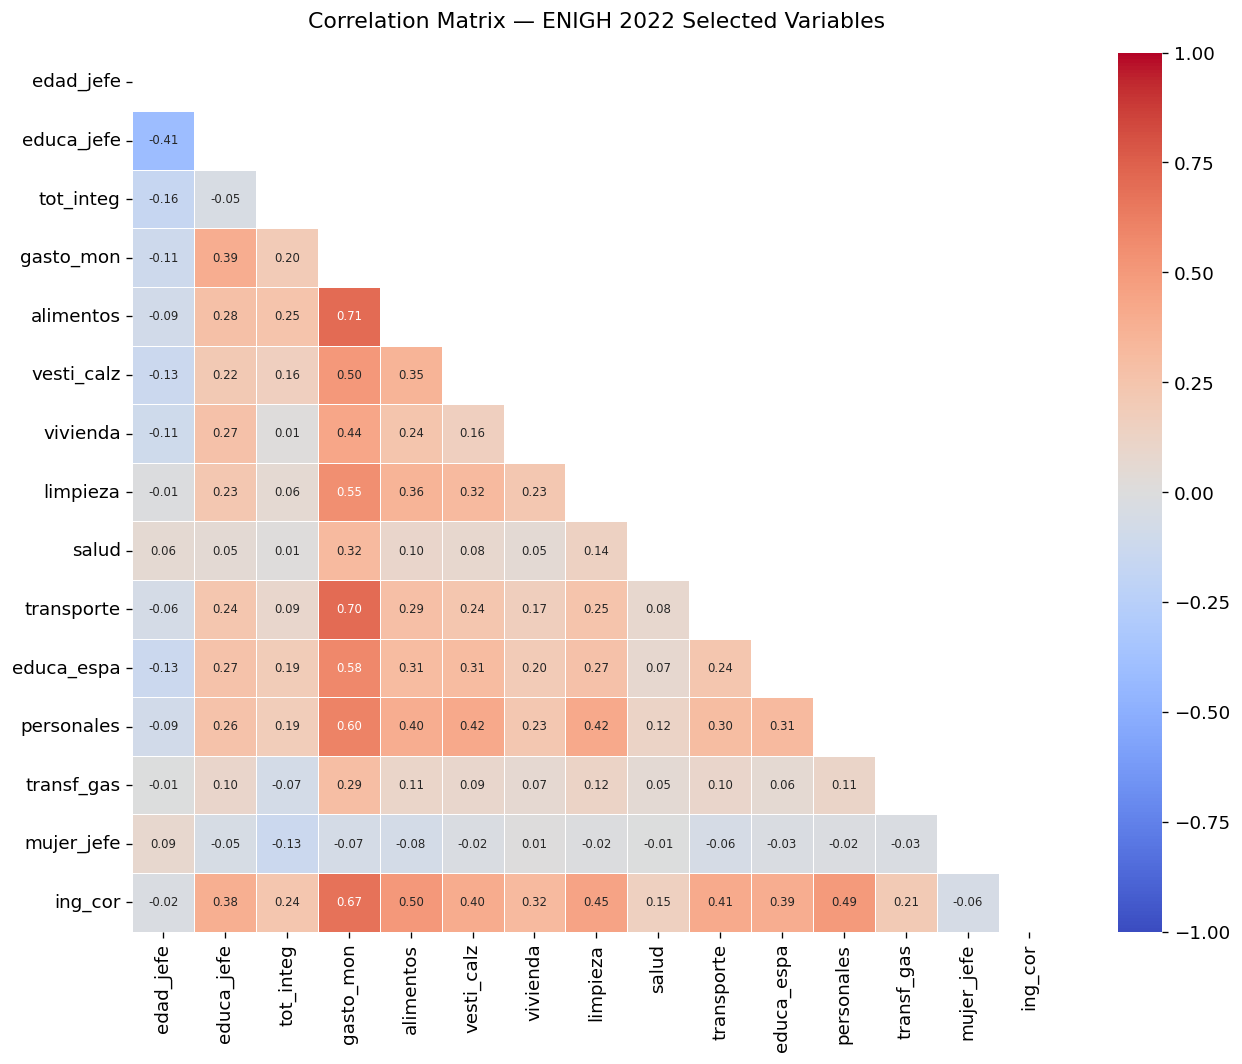

In [6]:
# --- Correlation heatmap ---
# Note: gasto_mon is the sum of all expenditure sub-categories.
# This creates near-perfect multicollinearity — a key motivation for regularization.
corr_cols = FEATURES + ['mujer_jefe', TARGET]
corr = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix — ENIGH 2022 Selected Variables', pad=15)
plt.tight_layout()
plt.show()

The heatmap reveals a key modeling challenge: `gasto_mon` (total expenditure) is by construction the **sum** of all expenditure sub-categories included as predictors. This introduces near-perfect multicollinearity — OLS will produce large, unstable coefficients as a result. Lasso and Ridge are specifically designed to handle this situation.

In [7]:
# --- Train/test split and feature scaling ---
# Scaling is required for regularized models: without it, variables with larger
# magnitudes would be penalized more heavily simply due to their units.

ALL_FEATURES = FEATURES + ['mujer_jefe']
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train only
X_test_sc  = scaler.transform(X_test)       # apply same transform to test

print(f'Training set : {X_train.shape[0]:,} observations')
print(f'Test set     : {X_test.shape[0]:,} observations')
print(f'Features     : {len(ALL_FEATURES)}')

Training set : 72,399 observations
Test set     : 18,100 observations
Features     : 14


<a id='ols'></a>
## 3. OLS Regression

**Ordinary Least Squares** minimizes the sum of squared residuals with no penalty:

$$\hat{\boldsymbol{\beta}}_{OLS} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2$$

OLS produces unbiased estimates, but in the presence of multicollinearity — as we have here — the estimates become highly variable and sensitive to small changes in the data.

In [8]:
# --- OLS ---
model_ols = LinearRegression()
model_ols.fit(X_train_sc, y_train)
y_pred_ols = model_ols.predict(X_test_sc)

r2_ols  = r2_score(y_test, y_pred_ols)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print('OLS Coefficients (standardized inputs):')
for name, coef in zip(ALL_FEATURES, model_ols.coef_):
    print(f'  {name:<15}: {coef:>12,.2f}')
print(f'  {"Intercept":<15}: {model_ols.intercept_:>12,.2f}')
print()
print(f'R²  : {r2_ols:.4f}')
print(f'RMSE: MXN {np.sqrt(mse_ols):,.0f}')

OLS Coefficients (standardized inputs):
  edad_jefe      :     7,855.28
  educa_jefe     :    10,514.08
  tot_integ      :     7,425.73
  gasto_mon      : 36,188,482,637,822,248.00
  alimentos      : -11,972,655,496,183,478.00
  vesti_calz     : -2,755,222,033,563,824.50
  vivienda       : -5,548,414,231,780,293.00
  limpieza       : -3,967,987,387,603,368.00
  salud          : -6,301,840,173,653,573.00
  transporte     : -15,061,371,410,284,010.00
  educa_espa     : -8,539,466,910,465,851.00
  personales     : -4,391,697,011,717,655.00
  transf_gas     : -5,380,742,344,770,202.00
  mujer_jefe     :      -327.77
  Intercept      :    67,958.25

R²  : 0.5345
RMSE: MXN 32,366


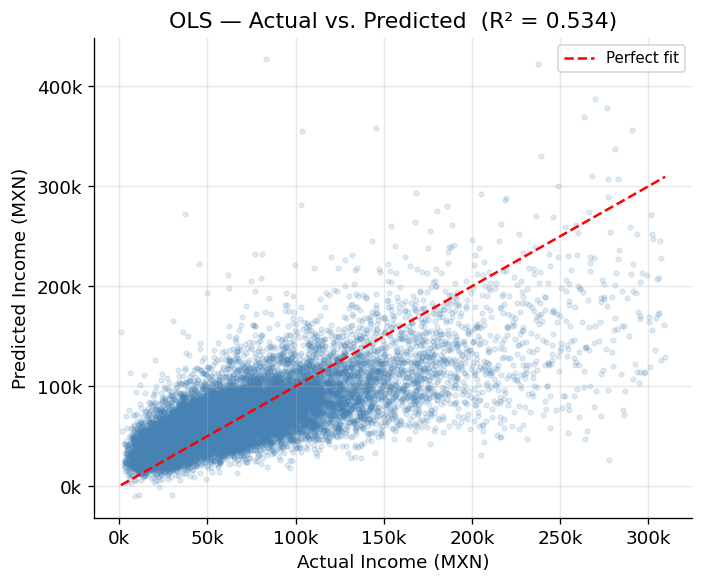

In [9]:
# --- OLS: Actual vs. Predicted ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_pred_ols, alpha=0.15, s=8, color='steelblue')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Actual Income (MXN)')
ax.set_ylabel('Predicted Income (MXN)')
ax.set_title(f'OLS — Actual vs. Predicted  (R² = {r2_ols:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='lasso'></a>
## 4. Lasso Regression (L1)

**Lasso** (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty to the OLS objective:

$$\hat{\boldsymbol{\beta}}_{Lasso} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2 + \lambda\sum_{j=1}^{p}|\beta_j|$$

The L1 penalty has a geometric property that causes some coefficients to be **exactly zero**, effectively removing those variables from the model. This makes Lasso a built-in variable selection method — particularly useful when many predictors are correlated or redundant.

### Choosing $\lambda$ with Cross-Validation

`LassoCV` trains the model across a grid of $\lambda$ values and selects the one that minimizes the average out-of-fold prediction error.

In [10]:
# --- Lasso with cross-validated alpha selection ---
model_lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
model_lasso.fit(X_train_sc, y_train)
y_pred_lasso = model_lasso.predict(X_test_sc)

r2_lasso  = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
n_zeroed  = np.sum(model_lasso.coef_ == 0)

print(f'Optimal λ (alpha) selected by 5-fold CV: {model_lasso.alpha_:.4f}')
print(f'Variables zeroed out: {n_zeroed} of {len(ALL_FEATURES)}')
print()
print('Lasso Coefficients:')
for name, coef in zip(ALL_FEATURES, model_lasso.coef_):
    flag = '  ← ZEROED (variable excluded)' if coef == 0 else ''
    print(f'  {name:<15}: {coef:>12,.2f}{flag}')
print()
print(f'R²  : {r2_lasso:.4f}')
print(f'RMSE: MXN {np.sqrt(mse_lasso):,.0f}')

Optimal λ (alpha) selected by 5-fold CV: 32.4087
Variables zeroed out: 1 of 14

Lasso Coefficients:
  edad_jefe      :     7,851.98
  educa_jefe     :    10,581.49
  tot_integ      :     7,436.30
  gasto_mon      :    17,395.19
  alimentos      :     2,298.72
  vesti_calz     :     2,931.03
  vivienda       :     2,102.25
  limpieza       :     4,500.67
  salud          :    -1,075.73
  transporte     :        -0.00  ← ZEROED (variable excluded)
  educa_espa     :       685.35
  personales     :     4,772.83
  transf_gas     :     2,693.85
  mujer_jefe     :      -298.44

R²  : 0.5344
RMSE: MXN 32,367


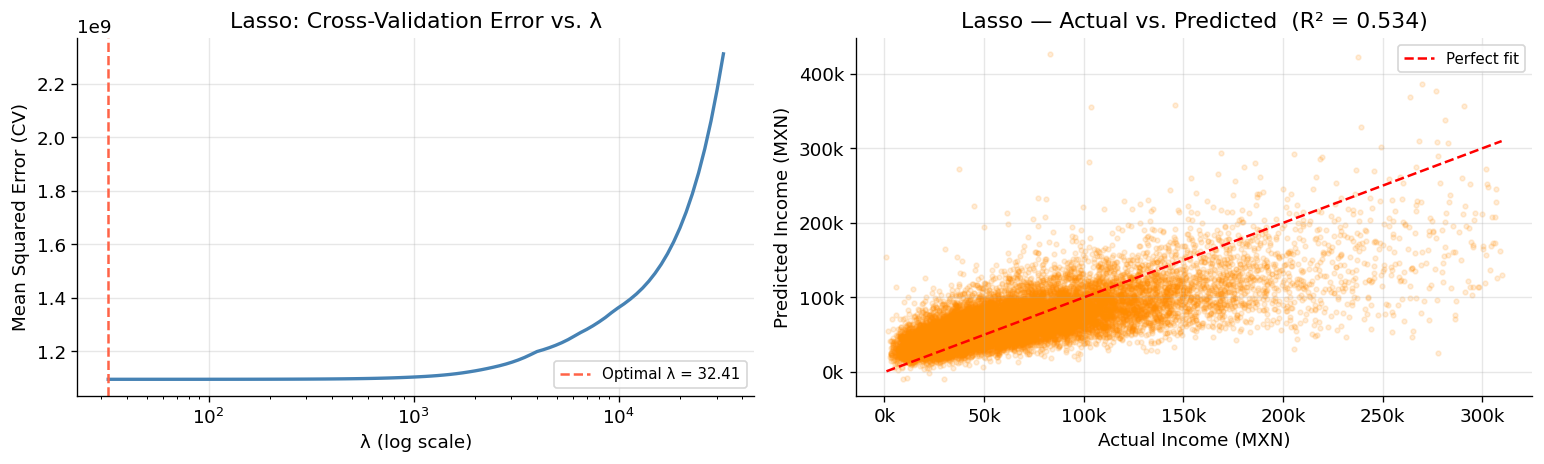

In [11]:
# --- Lasso CV path: how MSE varies with lambda ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CV error path
alphas   = model_lasso.alphas_
mse_path = model_lasso.mse_path_.mean(axis=1)

axes[0].semilogx(alphas, mse_path, color='steelblue', linewidth=2)
axes[0].axvline(model_lasso.alpha_, color='tomato', linestyle='--',
                label=f'Optimal λ = {model_lasso.alpha_:.2f}')
axes[0].set_xlabel('λ (log scale)')
axes[0].set_ylabel('Mean Squared Error (CV)')
axes[0].set_title('Lasso: Cross-Validation Error vs. λ')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_lasso, alpha=0.15, s=8, color='darkorange')
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].set_xlabel('Actual Income (MXN)')
axes[1].set_ylabel('Predicted Income (MXN)')
axes[1].set_title(f'Lasso — Actual vs. Predicted  (R² = {r2_lasso:.3f})')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id='ridge'></a>
## 5. Ridge Regression (L2)

**Ridge** adds an L2 penalty — the sum of squared coefficients:

$$\hat{\boldsymbol{\beta}}_{Ridge} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2 + \lambda\sum_{j=1}^{p}\beta_j^2$$

Unlike Lasso, Ridge **shrinks all coefficients toward zero but never to exactly zero** — all variables remain in the model. It is particularly effective when many predictors each contribute small, related effects. The bias-variance tradeoff: Ridge accepts some bias in exchange for a large reduction in variance, often improving out-of-sample predictions.

In [12]:
# --- Ridge with cross-validated alpha selection ---
model_ridge = RidgeCV(cv=5)
model_ridge.fit(X_train_sc, y_train)
y_pred_ridge = model_ridge.predict(X_test_sc)

r2_ridge  = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f'Optimal λ (alpha) selected by 5-fold CV: {model_ridge.alpha_:.4f}')
print()
print('Ridge Coefficients:')
for name, coef in zip(ALL_FEATURES, model_ridge.coef_):
    print(f'  {name:<15}: {coef:>12,.2f}')
print()
print(f'R²  : {r2_ridge:.4f}')
print(f'RMSE: MXN {np.sqrt(mse_ridge):,.0f}')

Optimal λ (alpha) selected by 5-fold CV: 10.0000

Ridge Coefficients:
  edad_jefe      :     7,919.28
  educa_jefe     :    10,629.28
  tot_integ      :     7,474.45
  gasto_mon      :     7,271.11
  alimentos      :     5,647.04
  vesti_calz     :     3,718.84
  vivienda       :     3,676.10
  limpieza       :     5,623.04
  salud          :       642.50
  transporte     :     4,183.45
  educa_espa     :     3,088.22
  personales     :     6,008.61
  transf_gas     :     4,227.75
  mujer_jefe     :      -329.61

R²  : 0.5344
RMSE: MXN 32,367


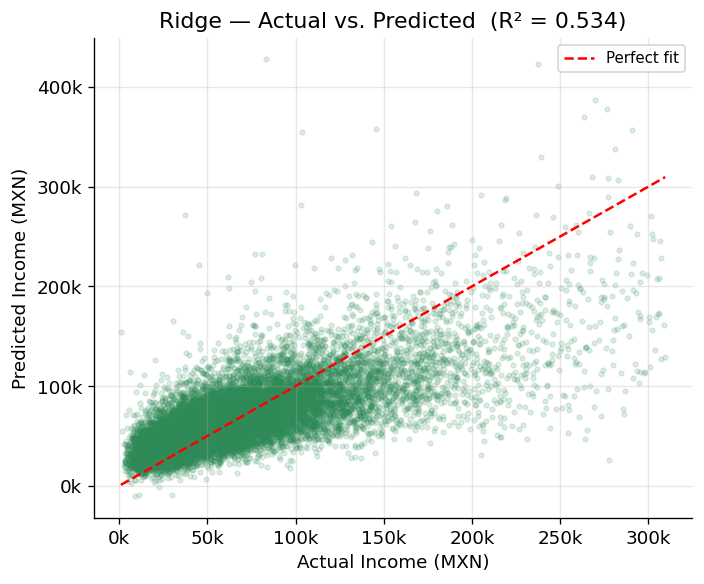

In [13]:
# --- Ridge: Actual vs. Predicted ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_pred_ridge, alpha=0.15, s=8, color='seagreen')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Actual Income (MXN)')
ax.set_ylabel('Predicted Income (MXN)')
ax.set_title(f'Ridge — Actual vs. Predicted  (R² = {r2_ridge:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='comparison'></a>
## 6. Model Comparison

We now compare the three models side by side — both in terms of predictive performance and how each treats the coefficients.

In [14]:
# --- Performance summary ---
results = pd.DataFrame({
    'Model' : ['OLS', 'Lasso (L1)', 'Ridge (L2)'],
    'λ (alpha)': ['-', f'{model_lasso.alpha_:.2f}', f'{model_ridge.alpha_:.2f}'],
    'R²'   : [r2_ols, r2_lasso, r2_ridge],
    'RMSE (MXN)': [np.sqrt(mse_ols), np.sqrt(mse_lasso), np.sqrt(mse_ridge)],
    'Vars zeroed': [0, int(np.sum(model_lasso.coef_ == 0)), 0]
})
results['R²'] = results['R²'].map('{:.4f}'.format)
results['RMSE (MXN)'] = results['RMSE (MXN)'].map('{:,.0f}'.format)
print(results.to_string(index=False))

     Model λ (alpha)     R² RMSE (MXN)  Vars zeroed
       OLS         - 0.5345     32,366            0
Lasso (L1)     32.41 0.5344     32,367            1
Ridge (L2)     10.00 0.5344     32,367            0


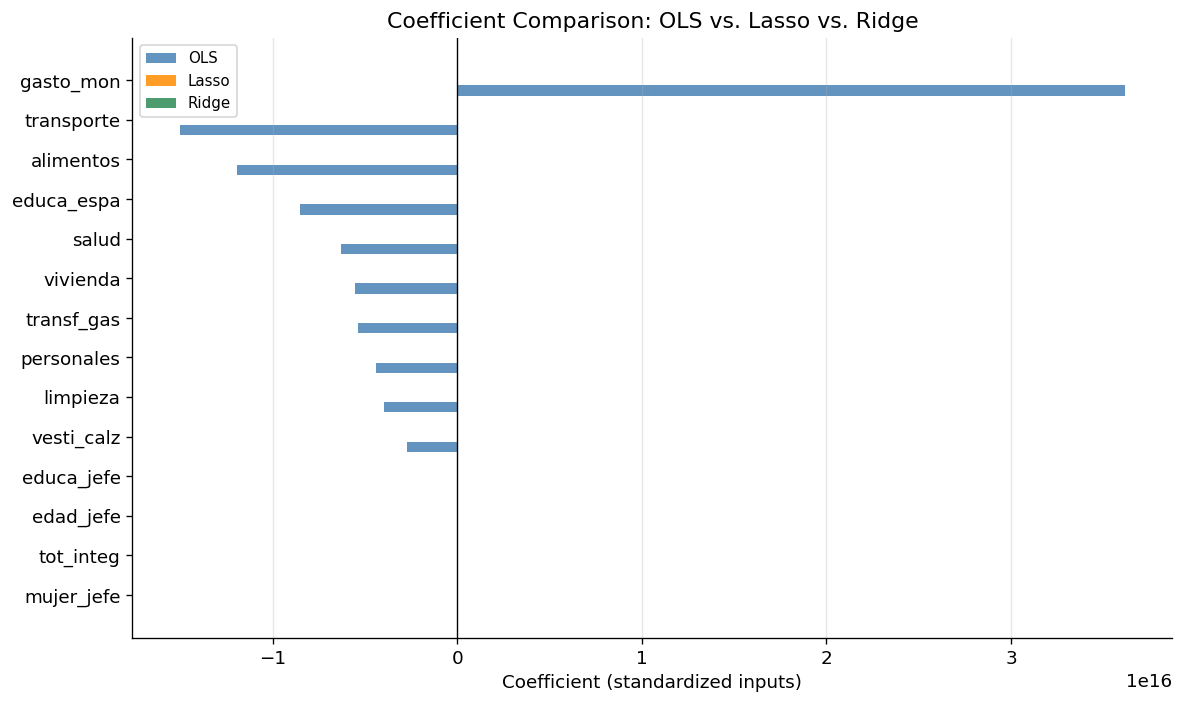

In [15]:
# --- Coefficient comparison plot ---
coef_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'OLS'   : model_ols.coef_,
    'Lasso' : model_lasso.coef_,
    'Ridge' : model_ridge.coef_
}).set_index('Feature')

# Sort by absolute OLS coefficient for readability
coef_df = coef_df.reindex(coef_df['OLS'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(coef_df))
width = 0.26

ax.barh(x - width, coef_df['OLS'],   width, label='OLS',   color='steelblue',  alpha=0.85)
ax.barh(x,         coef_df['Lasso'], width, label='Lasso', color='darkorange', alpha=0.85)
ax.barh(x + width, coef_df['Ridge'], width, label='Ridge', color='seagreen',   alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(coef_df.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized inputs)')
ax.set_title('Coefficient Comparison: OLS vs. Lasso vs. Ridge')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

<a id='summary'></a>
## 7. Summary & Key Takeaways

### Results

All three models achieve an R² of approximately **0.53** on the test set — a meaningful improvement over the unprocessed notebook (R² ≈ 0.28), primarily due to winsorizing extreme income values. The remaining unexplained variance reflects real complexity in income determination that goes beyond household expenditure structure.

### What the models tell us economically

- **Education** (`educa_jefe`) is the strongest demographic predictor of income, consistent with human capital theory.
- **`gasto_mon`** carries a large coefficient because it is collinear with income by construction — higher-income households spend more in aggregate.
- **Lasso zeroed out `transporte`**, suggesting that once total expenditure and other categories are controlled for, transportation spending adds no independent explanatory power for income.
- **`mujer_jefe`** (female household head) shows a consistently negative coefficient — female-headed households have lower average income, reflecting structural gender income gaps in Mexico.

### When to use each method

| Situation | Recommended method |
|-----------|-------------------|
| Few predictors, low multicollinearity | OLS |
| Many predictors, want automatic variable selection | **Lasso** |
| High multicollinearity, want to keep all predictors | **Ridge** |
| Both sparsity and multicollinearity | Elastic Net (combination of L1 + L2) |

Always select $\lambda$ via cross-validation — never use an arbitrary value like 0.1 without validation.

### Data source
INEGI (2022). *Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) 2022*. Instituto Nacional de Estadística y Geografía. https://www.inegi.org.mx/programas/enigh/nc/2022/